# Import Libraries

In [1]:
!pip install -q torch==2.9.0 cuda-bindings==12.9.5 "opentelemetry-api<=1.37.0" "opentelemetry-sdk<=1.37.0" unsloth trl peft accelerate bitsandbytes  deepeval datasets

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

%cd "/content/drive/My Drive/Fine-Tuning/Prism"

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
/content/drive/My Drive/Fine-Tuning/Prism


# 1. Import Libraries

In [3]:
import torch
import random
import numpy as np
import os
from dotenv import load_dotenv

SEED = 47
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

load_dotenv()

print(f"GPU: {torch.cuda.get_device_name(0)}")

GPU: NVIDIA A100-SXM4-80GB


# 2. Load and Explore Dataset

**Dataset**: medalpaca/medical_meadow_medical_flashcards<br>
**Model**: meta-llama/Llama-3.2-3B-Instruct

In [4]:
from datasets import load_dataset

dataset = load_dataset("medalpaca/medical_meadow_medical_flashcards", split="train")

print(f"Total Samples: {len(dataset)}")
print(f"Columns: {dataset.column_names}")
print("Example:")
print(f"\tInstruction: {dataset[0]['instruction'][:100]}")
print(f"\tInput: {dataset[0]['input'][:100]}")
print(f"\tOutput: {dataset[0]['output'][:200]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Total Samples: 33955
Columns: ['input', 'output', 'instruction']
Example:
	Instruction: Answer this question truthfully
	Input: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
	Output: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.


In [5]:
# Understanding the data - answer lengths, question types
answer_lengths = [len(ex["output"].split()) for ex in dataset]

print("Answer length (words):")
print(f"\tMin: {min(answer_lengths)}")
print(f"\tMean: {np.mean(answer_lengths):.0f}")
print(f"\tMax: {max(answer_lengths)}")

print("\n===== Sample Q&A pairs ======")
for idx in [0, 100, 500, 1000, 5000]:
  print(f"\nQuestion: {dataset[idx]['input'][:120]}")
  print(f"Answer: {dataset[idx]['output'][:150]}")

Answer length (words):
	Min: 0
	Mean: 54
	Max: 245

===== Sample Q&A pairs ======

Question: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
Answer: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.

Question: In which populations is α-thalassemia with a trans deletion more prevalent?
Answer: α-thalassemia with a trans deletion is more prevalent in African populations.

Question: What is pleomorphic adenoma and what are its components?
Answer: Pleomorphic adenoma is a type of salivary gland tumor that consists of chondromyxoid stroma and epithelium. This tumor can cause swelling, pain, and o

Question: What effect do upper motoneuron lesions have on muscle tone?
Answer: Upper motoneuron lesions may cause increased tone.

Question: In cases of meningitis, which type of meningitis is typically associated with a decrease in cerebrospinal fluid (CSF) su
Answer: Bacterial meningitis.


In [6]:
# Using just 10k rows out of 30k+ rows
TRAIN_SIZE = 10000
TEST_SIZE = 500

shuffled = dataset.shuffle(seed=SEED)
train_dataset = shuffled.select(range(TRAIN_SIZE))
test_dataset = shuffled.select(range(TRAIN_SIZE, TRAIN_SIZE + TEST_SIZE))

print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")

Train: 10000 | Test: 500


# 3. Load Model

In [7]:
from unsloth import FastLanguageModel

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [8]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="meta-llama/Llama-3.2-3B-Instruct",
    max_seq_length=2048,
    load_in_4bit=True,
)

for cfg in (model.config, getattr(model, "generation_config", None)):
  if cfg is None:
    continue
  if hasattr(cfg, "num_logits_to_keep"):
    try:
      delattr(cfg, "num_logits_to_keep")
    except Exception:
      cfg.num_logits_to_keep = None

==((====))==  Unsloth 2026.1.4: Fast Llama patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.35G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

# 4. Baseline Evaluation

In [9]:
SYSTEM_PROMPT = "You are a medical expert. Answer the following medical question accurately and concisely."

In [10]:
def generate_answer(model, tokenizer, question, max_tokens=512):
  messages = [
      {"role": "system", "content": SYSTEM_PROMPT},
      {"role": "user", "content": question},
  ]

  inputs = tokenizer.apply_chat_template(
      messages,
      add_generation_prompt=True,
      return_tensors="pt",
  ).to("cuda")

  with torch.no_grad():
    outputs = model.generate(
        input_ids=inputs,
        max_new_tokens=max_tokens,
        temperature=0.1,
        do_sample=False,
    )

  return tokenizer.decode(outputs[0][inputs.shape[-1]:], skip_special_tokens=True).strip()

In [11]:
EVAL_SIZE = 100
eval_sample = test_dataset.select(range(EVAL_SIZE))

# FastLanguageModel.for_inference(model) # Commented out to avoid 'num_logits_to_keep' error

print("Running Baseline inference.....")
baseline_preds = []
for i, example in enumerate(eval_sample):
  pred = generate_answer(model, tokenizer, example["input"])
  baseline_preds.append(pred)
  print(f"\t{i+1}/{EVAL_SIZE}", end="\r")

print(f"\t{EVAL_SIZE}/{EVAL_SIZE} done!")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Running Baseline inference.....


KeyboardInterrupt: 

In [ ]:
print("====== Baseline Results ========")
for i in range(5):
  print(f"\nQ: {eval_sample[i]['input'][:100]}")
  print(f"Expected: {eval_sample[i]['output'][:150]}")
  print(f"Baseline: {baseline_preds[i][:150]}")

## Rogue Score Evaluation

In [ ]:
!pip install -q rouge-score

In [ ]:
from rouge_score import rouge_scorer

In [ ]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(predictions, references):
  scores = {"rouge1": [], "rouge2": [], "rougeL": []}
  for pred, ref in zip(predictions, references):
    result = scorer.score(ref, pred)
    for key in scores:
      scores[key].append(result[key].fmeasure)
  return {k: np.mean(v) for k, v in scores.items()}

eval_references = [ex['output'] for ex in eval_sample]
baseline_rouge = compute_rouge(baseline_preds, eval_references)

print("Baseline ROUGE Scores:")
for metric, score in baseline_rouge.items():
  print(f"\t{metric}: {score:.4f}")

## Keyword Coverage

In [ ]:
def extract_medical_keywords(text, min_length=4):
  stop_words = {"that", "this", "with", "from", "have", "been", "were", "they",
                  "their", "which", "when", "what", "there", "also", "most",
                  "such", "than", "more", "into", "some", "other", "about"}

  words = set()
  for word in text.lower().split():
    cleaned = word.strip(".,;:!?()[]\"'")
    if len(cleaned) >= min_length and cleaned not in stop_words:
      words.add(cleaned)

  return words

def keyword_coverage(predictions, references):
  coverages = []
  for pred, ref in zip(predictions, references):
    ref_keywords = extract_medical_keywords(ref)
    pred_keywords = extract_medical_keywords(pred)
    if ref_keywords:
      coverage = len(ref_keywords & pred_keywords) / len(ref_keywords)
      coverages.append(coverage)
  return np.mean(coverages)

In [ ]:
baseline_keyword_cov = keyword_coverage(baseline_preds, eval_references)
print(f"Baseline Keyword Coverage: {baseline_keyword_cov:.4f}")

# 5. Fine-Tune Training

In [25]:
def format_for_training(example):
  messages = [
      {"role": "system", "content": SYSTEM_PROMPT},
      {"role": "user", "content": example["input"]},
      {"role": "assistant", "content": example["output"]},
  ]
  return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

In [26]:
train_formatter = train_dataset.map(format_for_training)

print("Formatted example:")
print(train_formatter[0]["text"][:500])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

NameError: name 'tokenizer' is not defined

## Apply LoRA & Training

In [23]:
model = FastLanguageModel.get_peft_model(
    model,
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth 2026.1.4 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [24]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Total Params: {total_params:,}")
print(f"Trainable Params: {trainable:,} - ({100*trainable/total_params:.2f}%)")

Total Params: 1,889,840,128
Trainable Params: 48,627,712 - (2.57%)


In [26]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_formatter,
    dataset_text_field="text",
    args=TrainingArguments(
        output_dir="./model/Llama3.2_3B_Instruct_checkpoints",
        per_device_train_batch_size=8,
        gradient_accumulation_steps=16,
        num_train_epochs=5,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        optim="adamw_8bit",
        weight_decay=0.01,
        max_grad_norm=1.0,
        bf16=True,
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    ),
    max_seq_length=2048,
)

Unsloth: Tokenizing ["text"] (num_proc=30):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [27]:
print("Starting training....")
train_result = trainer.train()

print("\nTraining completed!")
print(f"\tTotal steps: {train_result.global_step}")
print(f"\tFinal loss: {train_result.training_loss:.4f}")

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training....


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 5 | Total steps = 395
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 16 x 1) = 128
 "-____-"     Trainable parameters = 48,627,712 of 3,261,377,536 (1.49% trained)


Step,Training Loss
10,2.127800
20,0.970500
30,0.760200
40,0.701500
50,0.680300
60,0.671300
70,0.659300
80,0.640600
90,0.612100
100,0.616300



Training completed!
	Total steps: 395
	Final loss: 0.5753


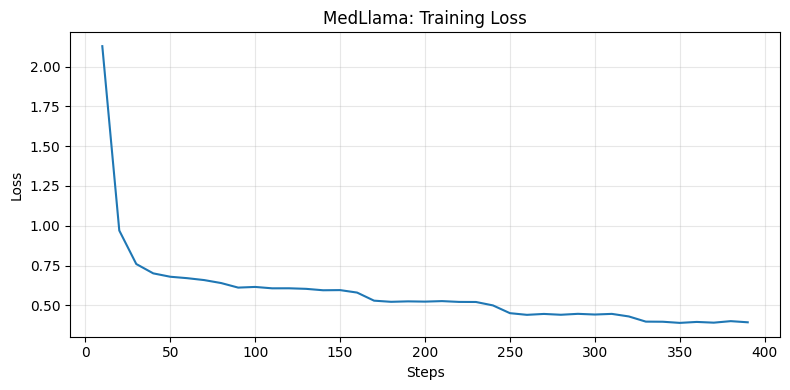

In [28]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"] for e in log_history if "loss" in e]

plt.figure(figsize=(8,4))
plt.plot(steps, losses, linewidth=1.5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("MedLlama: Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 6. Post-Training Evaluation

In [29]:
FastLanguageModel.for_inference(model)

print("Running fine-tuned inference....")
finetuned_preds = []
for i, example in enumerate(eval_sample):
  pred = generate_answer(model, tokenizer, example["input"])
  finetuned_preds.append(pred)
  print(f"\t{i+1}/{EVAL_SIZE}", end="\r")

print(f"\t{EVAL_SIZE}/{EVAL_SIZE} done!")

Running fine-tuned inference....
	100/100 done!


In [30]:
print("====== Baseline vs Fine-Tuned Results ========")
for i in range(5):
  print(f"\nQ: {eval_sample[i]['input'][:120]}")
  print(f"Expected: {eval_sample[i]['output'][:150]}")
  print(f"Baseline: {baseline_preds[i][:150]}")
  print(f"Fine-Tuned: {finetuned_preds[i][:150]}")

====== Baseline vs Fine-Tuned Results ========

Q: What is the recommended course of action if the fetal heart rate cannot be assessed using external methods during labor?
Expected: If the fetal heart rate cannot be assessed using external methods during labor, it is recommended to apply a fetal scalp electrode to monitor fetal we
Baseline: If the fetal heart rate cannot be assessed using external methods (e.g., fetal monitoring strips or electronic fetal monitoring) during labor, the rec
Fine-Tuned: If the fetal heart rate cannot be assessed using external methods during labor, the recommended course of action is to perform intermittent auscultati

Q: On electrophoresis, which hemoglobin type has the least far migration from the negative electrode?
Expected: HbC is the hemoglobin type that has the least far migration from the negative electrode on electrophoresis. Electrophoresis is a laboratory technique 
Baseline: In electrophoresis, the migration distance of a molecule is inversely

## Rouge + Keywords

In [33]:
finetuned_rouge = compute_rouge(finetuned_preds, eval_references)

print("="*50)
print("ROUGE COMPARISON")
print("="*50)
print(f"{'Metric':<12} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("="*50)
for metric in ["rouge1", "rouge2", "rougeL"]:
  base = baseline_rouge[metric]
  ft = finetuned_rouge[metric]
  print(f"{metric:>12} {base:>10.4f} {ft:>12.4f} {ft - base:>+10.4f}")

ROUGE COMPARISON
Metric         Baseline   Fine-tuned     Change
      rouge1     0.3521       0.4152    +0.0631
      rouge2     0.1909       0.2579    +0.0670
      rougeL     0.2601       0.3309    +0.0708


In [34]:
# keyword Coverage
finetuned_keyword_cov = keyword_coverage(finetuned_preds, eval_references)

print("Keyword Coverage:")
print(f"\tBaseline: {baseline_keyword_cov:.4f}")
print(f"\tFine-tuned: {finetuned_keyword_cov:.4f}")
print(f"\tChange: {finetuned_keyword_cov - baseline_keyword_cov:+.4f}")

Keyword Coverage:
	Baseline: 0.5279
	Fine-tuned: 0.4738
	Change: -0.0540


# 7. DeepEval Evaluation

In [40]:
JUDGE_SIZE = 30
judge_indices = random.sample(range(EVAL_SIZE), JUDGE_SIZE)

baseline_cases = []
finetuned_cases = []

for idx in judge_indices:
    question = eval_sample[idx]["input"]
    expected = eval_sample[idx]["output"]

    baseline_cases.append(LLMTestCase(
        input=question,
        actual_output=baseline_preds[idx],
        expected_output=expected,
    ))
    finetuned_cases.append(LLMTestCase(
        input=question,
        actual_output=finetuned_preds[idx],
        expected_output=expected,
    ))

print(f"Created {JUDGE_SIZE} test cases each for baseline and fine-tuned")

Created 30 test cases each for baseline and fine-tuned


In [53]:
import time
import random
import re
import json
import os
import asyncio
import requests
from typing import Any, Optional, Type
from pydantic import BaseModel
from deepeval.models import DeepEvalBaseLLM
from deepeval.metrics import GEval, AnswerRelevancyMetric
from deepeval.test_case import LLMTestCase, LLMTestCaseParams


def _extract_json_object(text: str) -> str | None:
    if not text:
        return None
    m = re.search(r"\{.*\}", text, flags=re.DOTALL)
    return m.group(0) if m else None

def _strip_code_fences(text: str) -> str:
    stripped = text.strip()
    if stripped.startswith("```"):
        lines = stripped.splitlines()
        if lines and lines[0].startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].startswith("```"):
            lines = lines[:-1]
        return "\n".join(lines).strip()
    return text


class OllamaAsJudge(DeepEvalBaseLLM):
    def __init__(
        self,
        model: str,
        api_key: str | None = None,
        base_url: str = "https://ollama.com",
        temperature: float = 0.0,
        generation_kwargs: Optional[dict] = None,
        force_json: bool = True,
        timeout_s: int = 120,
        max_retries: int = 5,
        max_concurrent: int = 1,
        sleep_between_calls_s: float = 0.2,
    ):
        self.model_name = model
        self.api_key = api_key or os.getenv("OLLAMA_API_KEY")
        self.base_url = base_url.rstrip("/")
        self.temperature = float(temperature)
        self.generation_kwargs = generation_kwargs or {}
        self._timeout_s = timeout_s
        self._max_retries = max_retries
        self._force_json = force_json
        self._sleep_between_calls_s = float(sleep_between_calls_s)

        if not self.api_key:
            raise ValueError("Missing OLLAMA_API_KEY. Set OLLAMA_API_KEY in your environment.")

        self._sem = asyncio.Semaphore(max_concurrent)

    def get_model_name(self) -> str:
        return f"ollama-cloud:{self.model_name}"

    def load_model(self) -> Any:
        return None

    def _request(self, payload: dict) -> dict:
        url = f"{self.base_url}/api/chat"
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json",
        }
        response = requests.post(url, headers=headers, json=payload, timeout=self._timeout_s)
        response.raise_for_status()
        return response.json()

    def generate(self, prompt: str, schema: Optional[Type[BaseModel]] = None):
        payload = {
            "model": self.model_name,
            "messages": [
                {
                    "role": "system",
                    "content": (
                        "You are a strict evaluation model that judges output of other llm models. "
                        "Return ONLY the required JSON (no markdown, no extra keys, no extra tokens)."
                    ),
                },
                {"role": "user", "content": prompt},
            ],
            "stream": False,
            "options": {
                "temperature": self.temperature,
                **self.generation_kwargs,
            },
        }

        if self._force_json:
            payload["format"] = "json"

        last_err = None
        for attempt in range(self._max_retries + 1):
            try:
                data = self._request(payload)
                if isinstance(data, dict) and data.get("error"):
                    raise RuntimeError(data["error"])

                content = (data.get("message") or {}).get("content")
                if not content:
                    content = data.get("response", "")
                content = _strip_code_fences((content or "")).strip()
                if not content:
                    raise ValueError("Empty judge response")

                if schema is None:
                    result = content
                else:
                    try:
                        result = schema.model_validate_json(content)
                    except Exception:
                        maybe = _extract_json_object(content)
                        if maybe is None:
                            raise
                        result = schema.model_validate(json.loads(maybe))

                if self._sleep_between_calls_s > 0:
                    time.sleep(self._sleep_between_calls_s)
                return result

            except requests.HTTPError as e:
                last_err = e
                status = getattr(e.response, "status_code", None)
                if status not in {429, 500, 502, 503, 504} or attempt == self._max_retries:
                    raise

            except (requests.RequestException, ValueError, RuntimeError) as e:
                last_err = e
                if attempt == self._max_retries:
                    raise

            backoff = min(10.0, 2 ** attempt) + random.uniform(0, 0.5)
            time.sleep(backoff)

        raise last_err

    async def a_generate(self, prompt: str, schema: Optional[Type[BaseModel]] = None) -> str:
        async with self._sem:
            result = await asyncio.to_thread(self.generate, prompt, schema)
            if self._sleep_between_calls_s > 0:
                await asyncio.sleep(self._sleep_between_calls_s)
            return result

In [60]:
JUDGE_MODEL_NAME = "deepseek-v3.1:671b-cloud"

judge = OllamaAsJudge(
    model=JUDGE_MODEL_NAME,
    temperature=0.0,
    generation_kwargs={
        "num_predict": 1024,
    },
    sleep_between_calls_s=0.2,
)

In [61]:
correctness_ollama = GEval(
    name="Medical Correctness (Ollama)",
    criteria=(
        "Determine if the actual output is medically correct based on the expected output. "
        "The actual output does not need to be word-for-word identical, but must convey "
        "the same medical facts and not contain incorrect medical information."
    ),
    evaluation_params=[
        LLMTestCaseParams.ACTUAL_OUTPUT,
        LLMTestCaseParams.EXPECTED_OUTPUT,
    ],
    threshold=0.5,
    model=judge,
    strict_mode=True,
)

In [62]:
relevancy_ollama = AnswerRelevancyMetric(model=judge, threshold=0.5)

In [63]:
if "baseline_cases" not in globals() or "finetuned_cases" not in globals():
    raise ValueError("Run the DeepEval test case construction cell before this one.")

In [64]:
def run_ollama_judge(test_cases, correctness_metric, relevancy_metric, label):
    results = []
    print(f"Evaluating {label} with Ollama LLM-as-Judge...")
    for i, tc in enumerate(test_cases):
        correctness_metric.measure(tc)
        c_score = correctness_metric.score

        relevancy_metric.measure(tc)
        r_score = relevancy_metric.score

        results.append({
            "i": i,
            "correctness_score": c_score,
            "relevancy_score": r_score,
        })
        print(f"  {i+1}/{len(test_cases)}", end="\r")
    print(f"  {len(test_cases)}/{len(test_cases)} done!")
    return results

In [65]:
baseline_results_ollama = run_ollama_judge(baseline_cases, correctness_ollama, relevancy_ollama, "BASELINE")
finetuned_results_ollama = run_ollama_judge(finetuned_cases, correctness_ollama, relevancy_ollama, "FINE-TUNED")

Output()

Evaluating BASELINE with Ollama LLM-as-Judge...


Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

  30/30 done!


In [66]:
base_correct = [r['correctness_score'] for r in baseline_results_ollama]
ft_correct = [r['correctness_score'] for r in finetuned_results_ollama]
base_relevancy = [r['relevancy_score'] for r in baseline_results_ollama]
ft_relevancy = [r['relevancy_score'] for r in finetuned_results_ollama]

In [67]:
print("="*50)
print("OLLAMA LLM-AS-JUDGE RESULTS")
print("="*50)
print(f"{'Metric':<25} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("-"*50)

if base_correct and ft_correct:
  bc, fc = np.mean(base_correct), np.mean(ft_correct)
  print(f"{'Medical Correctness':<25} {bc:>10.4f} {fc:>12.4f} {fc - bc:>+10.4f}")

if base_relevancy and ft_relevancy:
  br, fr = np.mean(base_relevancy), np.mean(ft_relevancy)
  print(f"{'Answer Relevancy':<25} {br:>10.4f} {fr:>12.4f} {fr - br:>+10.4f}")

OLLAMA LLM-AS-JUDGE RESULTS
Metric                      Baseline   Fine-tuned     Change
--------------------------------------------------
Medical Correctness           0.1667       0.1667    +0.0000
Answer Relevancy              0.9427       0.9015    -0.0411


## Error Analysis

In [68]:
ref_lengths = [len(r.split()) for r in eval_references]
base_lengths = [len(p.split()) for p in baseline_preds]
ft_lengths = [len(p.split()) for p in finetuned_preds]

print("Answer Length (words)")
print(f"\tReference: mean={np.mean(ref_lengths):.0f}, median={np.median(ref_lengths):.0f}")
print(f"\tBaseline: mean={np.mean(base_lengths):.0f}, median={np.median(base_lengths):.0f}")
print(f"\tFine-tuned: mean={np.mean(ft_lengths):.0f}, median={np.median(ft_lengths):.0f}")

Answer Length (words)
	Reference: mean=57, median=24
	Baseline: mean=104, median=106
	Fine-tuned: mean=55, median=24


### Worst Predictions

In [70]:
rougeL_scores = []
for pred, ref in zip(finetuned_preds, eval_references):
  result = scorer.score(ref, pred)
  rougeL_scores.append(result['rougeL'].fmeasure)

sorted_indices = np.argsort(rougeL_scores)

print("\n======== Worst Predictions (Lowest RougeL)=========")
for rank, idx in enumerate(sorted_indices[:5]):
  print(f"\n[Score: {rougeL_scores[idx]:.3f}]")
  print(f"\tQ: {eval_sample[idx]['input'][:100]}")
  print(f"\tExpected: {eval_references[idx][:120]}")
  print(f"\tfinetuned answered: {finetuned_preds[idx][:120]}")


======== Worst Predictions (Lowest RougeL)=========

[Score: 0.000]
	Q: 
	Expected: 
	finetuned answered: 

[Score: 0.053]
	Q: Which gender is more likely to experience migraines?
	Expected: Migraines are more common in females.
	finetuned answered: Women are more likely to experience migraines than men. Migraines are a type of headache disorder that can cause severe 

[Score: 0.104]
	Q: What is a complication of Bartonella henselae that specifically affects immunocompromised patients?
	Expected: Bacillary angiomatosis is a complication of Bartonella henselae that affects immunocompromised patients.
	finetuned answered: Bartonella henselae can cause a complication known as cat scratch fever, which is characterized by a rash and swelling a

[Score: 0.106]
	Q: What is the potential risk associated with the use of nonbenzodiazepine hypnotics in the elderly pop
	Expected: Nonbenzodiazepine hypnotics can cause central ataxia, which may lead to an increased risk of falls in the elderly.
	fi

### Best predictions

In [71]:
print("\n====== Best Predictions by the model (Highest RougeL) ======")
for rank, idx in enumerate(sorted_indices[-5:]):
  print(f"\n[Score: {rougeL_scores[idx]:.3f}]")
  print(f"\tQ: {eval_sample[idx]['input'][:100]}")
  print(f"\tExpected: {eval_references[idx][:120]}")
  print(f"\tFinetuned answered: {finetuned_preds[idx][:120]}")


====== Best Predictions by the model (Highest RougeL) ======

[Score: 0.733]
	Q: To which class of drugs does ifosfamide belong?
	Expected: Ifosfamide belongs to the class of drugs known as alkylating agents, which are cytotoxic chemotherapy drugs.
	Finetuned answered: Ifosfamide belongs to the class of drugs known as nitrosoureas, which are alkylating agents.

[Score: 0.800]
	Q: What is the effect of chronic PPI use on gastrin secretion?
	Expected: Chronic PPI use typically leads to an increase in gastrin secretion.
	Finetuned answered: Chronic PPI use can lead to increased gastrin secretion.

[Score: 0.800]
	Q: Between gastric and duodenal ulcers, which type of ulcer is more likely to be associated with malign
	Expected: Gastric ulcers are more likely to be malignant compared to duodenal ulcers.
	Finetuned answered: Gastric ulcers are more likely to be associated with malignancy than duodenal ulcers.

[Score: 0.800]
	Q: What types of infections are associated with deficiencies in B-

# 8. Save Model

In [73]:
model.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_lora_adapters", safe_serialization=True, max_shard_size="2GB")
tokenizer.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_lora_adapters")

('./model/Llama3.2_3B_Instruct_Medical_lora_adapters/tokenizer_config.json',
 './model/Llama3.2_3B_Instruct_Medical_lora_adapters/special_tokens_map.json',
 './model/Llama3.2_3B_Instruct_Medical_lora_adapters/chat_template.jinja',
 './model/Llama3.2_3B_Instruct_Medical_lora_adapters/tokenizer.json')

In [75]:
try:
  merged_model = model.merge_and_unload()
except Exception:
  merged_model = model

merged_model.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_bf16", safe_serialization=True, max_shard_size="2GB")
tokenizer.save_pretrained("./model/Llama3.2_3B_Instruct_Medical_bf16")
print("Saved model to ./model/Llama3.2_3B_Instruct_Medical_bf16")

/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Saved model to ./model/Llama3.2_3B_Instruct_Medical_bf16


# B. Qwen3 Model Experiment

In [8]:
model_qwen, tokenizer_qwen = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen3-4B-Instruct-2507",
    max_seq_length=512,
    load_in_4bit=True,
)

==((====))==  Unsloth 2026.1.4: Fast Qwen3 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.318 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 8.0. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.55G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

## Base Eval

In [9]:
SYSTEM_PROMPT = "You are a medical expert. Answer the following medical question accurately and concisely."

In [10]:
from tqdm.auto import tqdm

def generate_answer(model, tokenizer, questions, batch_size=16, max_tokens=512):
    # Ensure we have a list of questions
    if isinstance(questions, str):
        questions = [questions]
        single_input = True
    else:
        single_input = False

    # Configure tokenizer for batch generation
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = "left"

    all_answers = []

    # Process in batches
    for i in tqdm(range(0, len(questions), batch_size), desc="Batch Inference"):
        batch_qs = questions[i:i+batch_size]

        # 1. Format prompts using the chat template (without tokenizing yet)
        prompts = [
            tokenizer.apply_chat_template(
                [{"role": "system", "content": SYSTEM_PROMPT}, {"role": "user", "content": q}],
                tokenize=False,
                add_generation_prompt=True
            ) for q in batch_qs
        ]

        # 2. Tokenize the batch of prompts
        inputs = tokenizer(
            prompts,
            return_tensors="pt",
            padding=True,
            truncation=True,
        ).to("cuda")

        # 3. Generate
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_tokens,
                temperature=0.1,
                do_sample=False,
                use_cache=True
            )

        # 4. Decode (skipping the input prompt tokens)
        # We slice the output to exclude the input tokens
        generated_ids = outputs[:, inputs.input_ids.shape[1]:]
        decoded = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        all_answers.extend([d.strip() for d in decoded])

    if single_input:
        return all_answers[0]
    return all_answers

In [12]:
EVAL_SIZE = 100
eval_sample = test_dataset.select(range(EVAL_SIZE))

# FastLanguageModel.for_inference(model) # Commented out to avoid 'num_logits_to_keep' error

print("Running Baseline inference.....")
baseline_preds = []
for i, example in enumerate(eval_sample):
  pred = generate_answer(model_qwen, tokenizer_qwen, example["input"])
  baseline_preds.append(pred)
  print(f"\t{i+1}/{EVAL_SIZE}", end="\r")

print(f"\t{EVAL_SIZE}/{EVAL_SIZE} done!")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Running Baseline inference.....
	100/100 done!


In [13]:
!pip install -q rouge-score

  Preparing metadata (setup.py) ... done


In [14]:
from rouge_score import rouge_scorer

In [15]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def compute_rouge(predictions, references):
  scores = {"rouge1": [], "rouge2": [], "rougeL": []}
  for pred, ref in zip(predictions, references):
    result = scorer.score(ref, pred)
    for key in scores:
      scores[key].append(result[key].fmeasure)
  return {k: np.mean(v) for k, v in scores.items()}

eval_references = [ex['output'] for ex in eval_sample]
baseline_rouge = compute_rouge(baseline_preds, eval_references)

print("Baseline ROUGE Scores:")
for metric, score in baseline_rouge.items():
  print(f"\t{metric}: {score:.4f}")

Baseline ROUGE Scores:
	rouge1: 0.3224
	rouge2: 0.1627
	rougeL: 0.2239


In [16]:
def extract_medical_keywords(text, min_length=4):
  stop_words = {"that", "this", "with", "from", "have", "been", "were", "they",
                  "their", "which", "when", "what", "there", "also", "most",
                  "such", "than", "more", "into", "some", "other", "about"}

  words = set()
  for word in text.lower().split():
    cleaned = word.strip(".,;:!?()[]\"'")
    if len(cleaned) >= min_length and cleaned not in stop_words:
      words.add(cleaned)

  return words

def keyword_coverage(predictions, references):
  coverages = []
  for pred, ref in zip(predictions, references):
    ref_keywords = extract_medical_keywords(ref)
    pred_keywords = extract_medical_keywords(pred)
    if ref_keywords:
      coverage = len(ref_keywords & pred_keywords) / len(ref_keywords)
      coverages.append(coverage)
  return np.mean(coverages)

In [17]:
baseline_keyword_cov = keyword_coverage(baseline_preds, eval_references)
print(f"Baseline Keyword Coverage: {baseline_keyword_cov:.4f}")

Baseline Keyword Coverage: 0.5642


## Fine-tuning Qwen3 Instruct

In [27]:
def format_for_training(example):
  messages = [
      {"role": "system", "content": SYSTEM_PROMPT},
      {"role": "user", "content": example["input"]},
      {"role": "assistant", "content": example["output"]},
  ]
  return {"text": tokenizer_qwen.apply_chat_template(messages, tokenize=False)}

In [28]:
train_formatter = train_dataset.map(format_for_training)

print("Formatted example:")
print(train_formatter[0]["text"][:500])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Formatted example:
<|im_start|>system
You are a medical expert. Answer the following medical question accurately and concisely.<|im_end|>
<|im_start|>user
What diagnostic methods are used to identify meconium ileus?<|im_end|>
<|im_start|>assistant
<think>

</think>

Meconium ileus can be diagnosed using a variety of methods, including X-ray imaging. X-rays can reveal the presence of intestinal obstruction, which is a hallmark feature of meconium ileus. Other diagnostic methods that may be used include abdominal ul


In [20]:
model_qwen = FastLanguageModel.get_peft_model(
    model_qwen,
    r=32,
    lora_alpha=64,
    lora_dropout=0.05,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    use_gradient_checkpointing="unsloth",
    random_state=SEED,
)

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.1.4 patched 36 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


In [22]:
trainable = sum(p.numel() for p in model_qwen.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model_qwen.parameters())

print(f"Total Params: {total_params:,}")
print(f"Trainable Params: {trainable:,} - ({100*trainable/total_params:.2f}%)")

Total Params: 2,572,680,704
Trainable Params: 66,060,288 - (2.57%)


In [29]:
from trl import SFTTrainer
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model_qwen,
    tokenizer=tokenizer_qwen,
    train_dataset=train_formatter,
    dataset_text_field="text",
    args=TrainingArguments(
        output_dir="./model/Qwen3_4B_Instruct_Medical_checkpoints",
        per_device_train_batch_size=8,
        gradient_accumulation_steps=16,
        num_train_epochs=5,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_ratio=0.05,
        optim="adamw_8bit",
        weight_decay=0.01,
        max_grad_norm=1.0,
        bf16=True,
        logging_steps=10,
        save_strategy="epoch",
        save_total_limit=2,
        report_to="none",
        seed=SEED,
    ),
    max_seq_length=1024,
)

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/10000 [00:00<?, ? examples/s]

In [30]:
print("Starting training....")
train_result = trainer.train()

print("\nTraining completed!")
print(f"\tTotal steps: {train_result.global_step}")
print(f"\tFinal loss: {train_result.training_loss:.4f}")

The model is already on multiple devices. Skipping the move to device specified in `args`.


Starting training....


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 10,000 | Num Epochs = 5 | Total steps = 395
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 16
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 16 x 1) = 128
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Step,Training Loss
10,2.359600
20,1.004100
30,0.821700
40,0.781900
50,0.749600
60,0.730700
70,0.723100
80,0.696400
90,0.660600
100,0.670700



Training completed!
	Total steps: 395
	Final loss: 0.6315


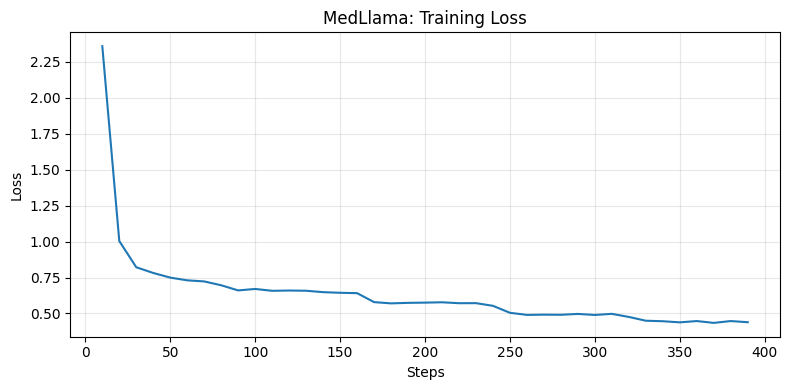

In [31]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [e["step"] for e in log_history if "loss" in e]
losses = [e["loss"] for e in log_history if "loss" in e]

plt.figure(figsize=(8,4))
plt.plot(steps, losses, linewidth=1.5)
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("MedLlama: Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Post Fine-Tune Eval

In [33]:
FastLanguageModel.for_inference(model_qwen)

print("Running fine-tuned inference (Batch)....")

# Pass the list of inputs directly to the batch-enabled function
qwen_finetuned_preds = generate_answer(
    model_qwen,
    tokenizer_qwen,
    eval_sample["input"],
    batch_size=8
)

print(f"\nDone! Generated {len(qwen_finetuned_preds)} answers.")

Running fine-tuned inference....
	100/100 done!


In [35]:
print("====== Baseline vs Fine-Tuned Results ========")
for i in range(5):
  print(f"\nQ: {eval_sample[i]['input'][:120]}")
  print(f"Expected: {eval_sample[i]['output'][:150]}")
  print(f"Baseline: {baseline_preds[i][:150]}")
  print(f"Fine-Tuned: {qwen_finetuned_preds[i][:150]}")

====== Baseline vs Fine-Tuned Results ========

Q: What is the recommended course of action if the fetal heart rate cannot be assessed using external methods during labor?
Expected: If the fetal heart rate cannot be assessed using external methods during labor, it is recommended to apply a fetal scalp electrode to monitor fetal we
Baseline: If the fetal heart rate cannot be assessed using external methods (such as fetal heart rate monitoring) during labor, the recommended course of action
Fine-Tuned: <think>

</think>

If the fetal heart rate cannot be assessed using external methods during labor, the recommended course of action is to perform an a

Q: On electrophoresis, which hemoglobin type has the least far migration from the negative electrode?
Expected: HbC is the hemoglobin type that has the least far migration from the negative electrode on electrophoresis. Electrophoresis is a laboratory technique 
Baseline: On electrophoresis, **hemoglobin S (HbS)** has the least far migratio

In [36]:
qwen_finetuned_rouge = compute_rouge(qwen_finetuned_preds, eval_references)

print("="*50)
print("ROUGE COMPARISON")
print("="*50)
print(f"{'Metric':<12} {'Baseline':>10} {'Fine-tuned':>12} {'Change':>10}")
print("="*50)
for metric in ["rouge1", "rouge2", "rougeL"]:
  base = baseline_rouge[metric]
  ft = qwen_finetuned_rouge[metric]
  print(f"{metric:>12} {base:>10.4f} {ft:>12.4f} {ft - base:>+10.4f}")

ROUGE COMPARISON
Metric         Baseline   Fine-tuned     Change
      rouge1     0.3224       0.4591    +0.1367
      rouge2     0.1627       0.3057    +0.1430
      rougeL     0.2239       0.3802    +0.1562


In [38]:
# keyword Coverage
qwen_finetuned_keyword_cov = keyword_coverage(qwen_finetuned_preds, eval_references)

print("Keyword Coverage:")
print(f"\tBaseline: {baseline_keyword_cov:.4f}")
print(f"\tFine-tuned: {qwen_finetuned_keyword_cov:.4f}")
print(f"\tChange: {qwen_finetuned_keyword_cov - baseline_keyword_cov:+.4f}")

Keyword Coverage:
	Baseline: 0.5642
	Fine-tuned: 0.5153
	Change: -0.0489
